In [7]:
# SPDFI
# setup
# preprocess
# detect / feature extraction
# find + filter match
# inference

import os
import cv2
import matplotlib.pyplot as plt

In [8]:
# # optional algorithm notes + examples (cell 2 only)

# # Feature extractor options (example use):
# # SIFT (float descriptor, robust, slower)
# siftExtractor = cv2.SIFT_create() if hasattr(cv2, "SIFT_create") else None
# # example: kp, desc = siftExtractor.detectAndCompute(grayImage, None)

# # ORB (binary descriptor, very fast)
# orbExtractor = cv2.ORB_create(nfeatures=2000)
# # example: kp, desc = orbExtractor.detectAndCompute(grayImage, None)

# # AKAZE (binary descriptor, good balance)
# akazeExtractor = cv2.AKAZE_create()
# # example: kp, desc = akazeExtractor.detectAndCompute(grayImage, None)

# # BRISK (binary descriptor, fast alternative)
# briskExtractor = cv2.BRISK_create()
# # example: kp, desc = briskExtractor.detectAndCompute(grayImage, None)

# # KAZE (float descriptor, robust, slower than AKAZE/ORB)
# kazeExtractor = cv2.KAZE_create()
# # example: kp, desc = kazeExtractor.detectAndCompute(grayImage, None)

# # Preprocess options before detect (example use):
# # CLAHE: better local contrast
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# # example: enhancedGray = clahe.apply(grayImage)

# # Median blur: salt-pepper noise
# # example: medianImage = cv2.medianBlur(grayImage, 3)

# # Gaussian blur: general noise smoothing
# # example: gaussianImage = cv2.GaussianBlur(grayImage, (3, 3), 0)

# # Matcher options (example use):
# # BF + Hamming (for ORB/AKAZE/BRISK binary descriptors)
# bfHamming = cv2.BFMatcher(cv2.NORM_HAMMING)
# # example: knnMatches = bfHamming.knnMatch(desc1, desc2, k=2)

# # BF + L2 (for SIFT/KAZE float descriptors)
# bfL2 = cv2.BFMatcher(cv2.NORM_L2)
# # example: knnMatches = bfL2.knnMatch(desc1, desc2, k=2)

# # FLANN (commonly for float descriptors, large dataset)
# flannMatcher = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
# # example: knnMatches = flannMatcher.knnMatch(np.float32(desc1), np.float32(desc2), k=2)

# # Notes-only selector (quick recall):
# selectedExtractor = "AKAZE"      # SIFT | ORB | AKAZE | BRISK | KAZE
# selectedPreprocess = "MEDIAN"    # NONE | CLAHE | MEDIAN | GAUSSIAN
# selectedMatcher = "BF_HAMMING"   # BF_HAMMING | BF_L2 | FLANN

In [9]:
# prepro
targetImagePath = "./CV_Session6/Dataset/Object.jpg"
candidateFolderPath = "./CV_Session6/Dataset/Data/"

In [10]:
# prepro
targetBgr = cv2.imread(targetImagePath)
targetRgb = cv2.cvtColor(targetBgr, cv2.COLOR_BGR2RGB)
targetGrayBlur = cv2.medianBlur(cv2.cvtColor(targetBgr, cv2.COLOR_BGR2GRAY), 3)

candidates = []
for fileName in os.listdir(candidateFolderPath):
    candidateBgr = cv2.imread(os.path.join(candidateFolderPath, fileName))
    if candidateBgr is not None:
        candidates.append((fileName, candidateBgr))

print("Loaded images:", len(candidates))

Loaded images: 5


In [11]:
# detect
akaze = cv2.AKAZE_create()
targetKeypoints, targetDescriptors = akaze.detectAndCompute(targetGrayBlur, None)

bestMatchCount = 0

In [12]:
# find + filter match (more accurate for AKAZE binary descriptors)

# matcher pilih salah 1 flann or BFMatcher
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
bfMatcher = cv2.BFMatcher(cv2.NORM_HAMMING)

for fileName, candidateBgr in candidates:
    candidateGrayBlur = cv2.medianBlur(cv2.cvtColor(candidateBgr, cv2.COLOR_BGR2GRAY), 3)
    candidateKeypoints, candidateDescriptors = akaze.detectAndCompute(candidateGrayBlur, None)

    knnMatches = bfMatcher.knnMatch(targetDescriptors, candidateDescriptors, k=2)

    goodMatches = []
    for matchPair in knnMatches:
        firstMatch, secondMatch = matchPair

        if firstMatch.distance < 0.75 * secondMatch.distance:
            goodMatches.append(firstMatch)

    if bestMatchCount < len(goodMatches):
        bestMatchCount = len(goodMatches)
        bestMatchData = {
            "fileName": fileName,
            "imageBgr": candidateBgr,
            "keypoints": candidateKeypoints,
            "goodMatches": sorted(goodMatches, key=lambda m: m.distance)[:120],
        }

if bestMatchCount == 0:
    raise RuntimeError("No good matches found")

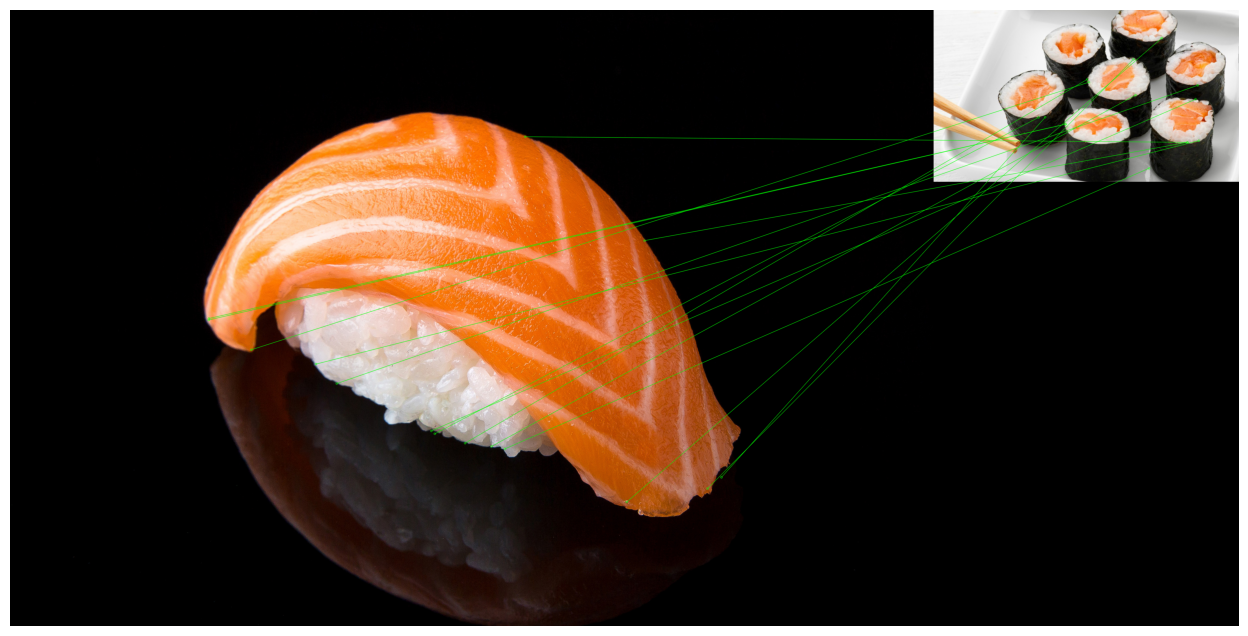

In [13]:
# inference
bestImageRgb = cv2.cvtColor(bestMatchData["imageBgr"], cv2.COLOR_BGR2RGB)

result = cv2.drawMatches(
    targetRgb,
    targetKeypoints,
    bestImageRgb,
    bestMatchData["keypoints"],
    bestMatchData["goodMatches"],
    None,
    matchColor=(0,255,0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 8))
plt.imshow(result)
plt.axis("off")
plt.show()